In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils2 import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils2 import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [2]:
def softmax(x, tau=1.0):
    x = np.asarray(x, dtype=float)
    z = (x - np.max(x)) / tau   # numerical stability
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

def tau_schedule(delta_t, tau0=2.0, tau_min=0.05, decay=0.98):
    return max(tau_min, tau0 * (decay ** delta_t))

In [3]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [4]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [88]:
gamma = 0.9
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
Ts = [128]

threshold = 1e-4
## Onehot Encoding
for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        np.random.shuffle(irewards)
        for T in Ts:
            prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
            X_train_oh = new_state_oh[:T,:]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]
   
            rf_value = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_value.fit(X_train_oh, Y_train_value)

            
            rf_action = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_action.fit(X_train_oh, Y_train_action)

            print(T,'train done')
            current_state = states[T,0]
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf_action.predict(features)
                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)

                cand_pe = position_encoder(df_all_paths.iloc[:,-1], type='onehot')
                curr_time = T+1+delta_t+t_prime+1
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                
                prewards_pred = rf_value.predict(features)
                df_ireward[f"preward"] = prewards_pred
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(0, t_prime+1)

                discounted_returns = rewards_matrix * discounts # PVAFM

                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5,normalization = True)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization = True)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            if T == 256:
                plt.plot(np.arange(T+1,T+101),future_states[1:])
                plt.plot(np.arange(T,T+101),path)
                plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PVAFM/GBT_oh_gamma0.9_weighted_w_t0_lookahead{t_prime}_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )


128 train done
128 [np.float64(1.0), 2, 2, 3, 2, 3, 3, 3, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 3, 2, 2, 1, 2, 2, 2, 3, 4, 5, 4, 3, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 1] 101
2.2192429834513323
128 train done
128 [np.float64(2.0), 1, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 4, 4, 3, 2, 2, 2, 1, 2, 2, 2, 2, 3, 2, 2, 1, 2, 3, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 2, 2, 3, 4, 3, 2, 2, 2, 3, 4, 3, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 3, 2] 101
2.299881173806944
128 train done
128 [np.float64(5.0), 4, 3, 2, 3, 3, 3, 2, 1, 0, 0, 0, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 0, 0, 0, 1, 2, 1, 0, 0, 1, 0, 0, 0, 1, 2, 3, 3, 3, 3, 3, 3, 2, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 4, 4, 3, 2, 2, 2, 1

In [ ]:
gamma = 0.9
Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]

threshold = 1e-4
## Onehot Encoding
for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
            prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
            X_train_oh = new_state_oh[:T,:]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]

            rf_value = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_value.fit(X_train_oh, Y_train_value)

            
            rf_action = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_action.fit(X_train_oh, Y_train_action)

            print(T,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf_action.predict(features)
                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)

                cand_pe = position_encoder(df_all_paths.iloc[:,-1], type='onehot')
                curr_time = T+1+delta_t+t_prime+1
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                
                prewards_pred = rf_value.predict(features)
                df_ireward[f"preward"] = prewards_pred
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(0, t_prime+1)

                discounted_returns = rewards_matrix * discounts # PVAFM

                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                future_states.append(next_state)
                current_state = next_state
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5,normalization = True)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization = True)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            if T == 256:
                plt.plot(np.arange(T+1,T+101),future_states[1:])
                plt.plot(np.arange(T,T+101),path)
                plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PVAFM/GBT_oh_gamma0.9_weighted_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )


### Softmax exploration

128 train done
128 [np.float64(1.0), 2, 1, 2, 3, 4, 5, 6, 5, 5, 5, 5, 5, 4, 5, 6, 5, 5, 6, 5, 5, 4, 3, 3, 4, 5, 4, 5, 5, 4, 3, 2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 5, 5, 6, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1] 101
1.1235261971195745
256 train done
256 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 4, 4, 5, 5, 5, 4, 5, 5, 4, 3, 2, 2, 1, 1, 1, 2, 3, 2, 3, 4, 4, 4, 5, 5, 6, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 0, 1, 2, 3, 3, 4, 4, 5, 5, 5, 6, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 2, 3, 4, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 4, 5, 5, 5, 5, 5, 5, 4] 101
0.23975995845471487


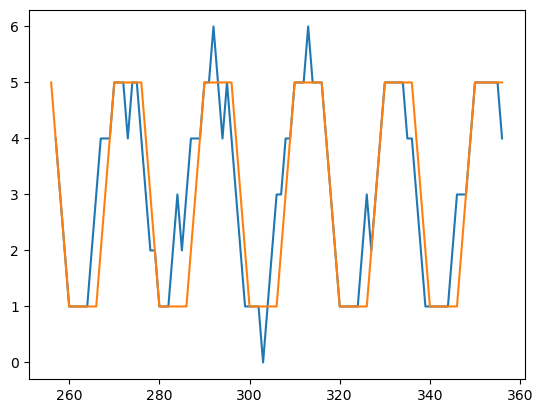

512 train done
512 [np.float64(4.0), 5, 4, 4, 5, 4, 3, 2, 1, 1, 1, 0, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 4, 4, 5, 4, 3, 2, 1, 1, 1, 1, 2, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 0, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 3, 4, 5, 5, 5] 101
0.1318888597884336
750 train done
750 [np.float64(3.0), 4, 5, 5, 4, 3, 4, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 2, 1, 2, 1, 1, 1, 1, 0, 1, 2, 3, 3, 4, 5, 5, 5, 5, 6, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5] 101
0.10878567972934831
1024 train done
1024 [np.float64(2.0), 2, 3, 3, 3, 4, 5, 5, 4, 3, 4, 3, 2, 1, 0, 0, 1, 1, 2, 2, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 4, 3, 3, 4, 3, 2, 1, 1, 1, 2, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 6, 6, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 3, 2, 2, 1, 1, 1, 1, 1, 

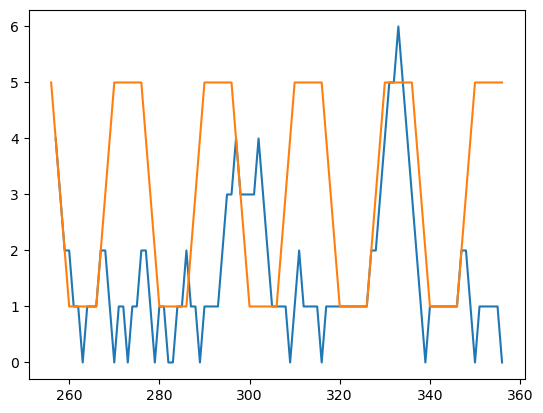

512 train done
512 [np.float64(4.0), 5, 4, 3, 2, 1, 1, 2, 1, 2, 3, 3, 3, 3, 4, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 0, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 4, 3, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 3, 4, 4, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5] 101
0.27647470785113515
750 train done
750 [np.float64(4.0), 3, 3, 4, 3, 3, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 3, 2, 3, 4, 5, 5, 5, 6, 5, 4, 3, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 2, 3, 4, 5, 5, 5, 4, 4, 4, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 6, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.22271887225529555
1024 train done
1024 [np.float64(4.0), 4, 4, 5, 6, 6, 5, 5, 5, 6, 5, 6, 5, 4, 3, 2, 1, 1, 1, 2, 1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 2, 2, 1, 1, 1, 0, 1, 2, 3, 3, 4, 5, 5, 5, 6, 5, 5, 4, 3, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1,

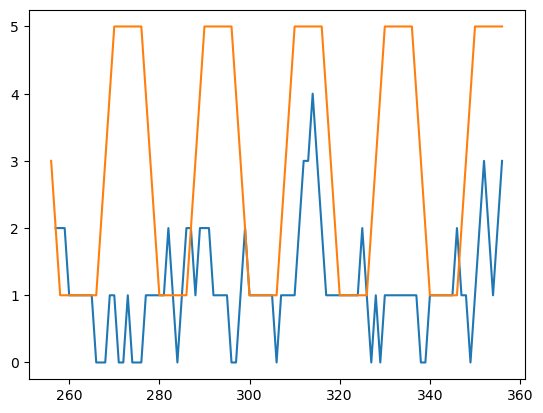

512 train done
512 [np.float64(5.0), 6, 6, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 2, 1, 0, 0, 0, 1, 2, 3, 3, 2, 1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 3, 3, 4, 3, 3, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5] 101
1.2161899951306459
750 train done
750 [np.float64(0.0), 0, 1, 0, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 6, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 6, 5, 4, 3, 2, 1, 1, 1, 0, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 4, 4, 4, 5] 101
0.12576216471821453
1024 train done
1024 [np.float64(2.0), 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 6, 5, 4, 3, 2, 1, 0, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 

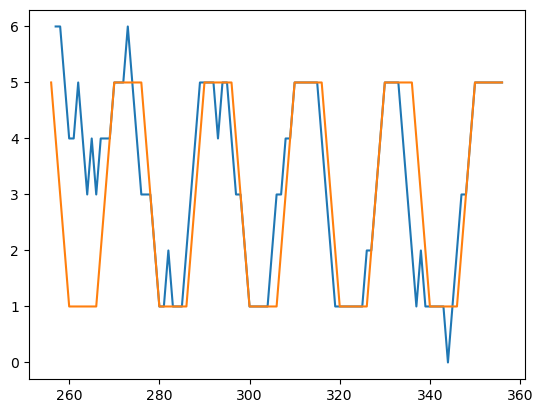

512 train done
512 [np.float64(3.0), 4, 4, 5, 5, 5, 4, 3, 4, 3, 2, 1, 2, 3, 4, 3, 4, 4, 5, 4, 4, 3, 3, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5] 101
0.5051402036033323
750 train done
750 [np.float64(3.0), 4, 5, 6, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 0, 1, 1, 1, 2, 3, 4, 5, 5, 6, 6, 5, 4, 3, 3, 2, 1, 1, 1, 0, 1, 1, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 4, 4, 5, 5, 5, 5, 4, 4, 3, 2, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.24354439812701004
1024 train done
1024 [np.float64(4.0), 5, 6, 5, 5, 4, 5, 5, 5, 6, 5, 4, 3, 2, 1, 0, 1, 1, 1, 1, 2, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 2, 1, 1, 1, 0, 1, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 2, 2, 1, 1, 1, 1, 1, 

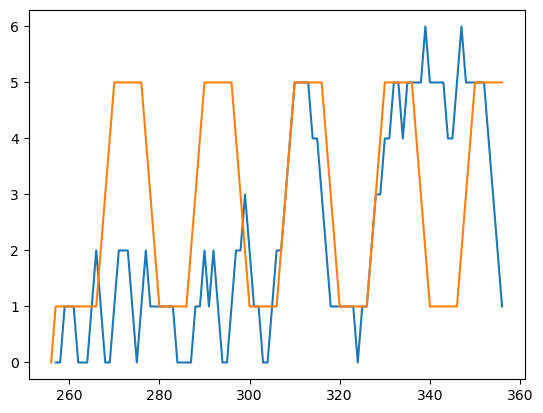

512 train done
512 [np.float64(5.0), 5, 4, 4, 4, 3, 2, 1, 1, 1, 1, 1, 2, 2, 3, 3, 2, 2, 3, 4, 5, 5, 5, 4, 3, 3, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 4, 5, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 3, 4, 5, 5, 5] 101
0.3333318516312349
750 train done
750 [np.float64(2.0), 3, 4, 3, 4, 3, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 3, 4, 5, 6, 6, 5, 6, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 1, 2, 3, 4, 5, 5, 5, 4, 3, 2, 3, 2, 3, 2, 1, 1, 1, 1, 1, 2, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.3344911515014658
1024 train done
1024 [np.float64(0.0), 1, 1, 2, 3, 4, 5, 5, 6, 6, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 4, 5, 5, 5, 5, 5, 4, 3, 3, 3, 2, 1, 1, 1, 1, 1, 2

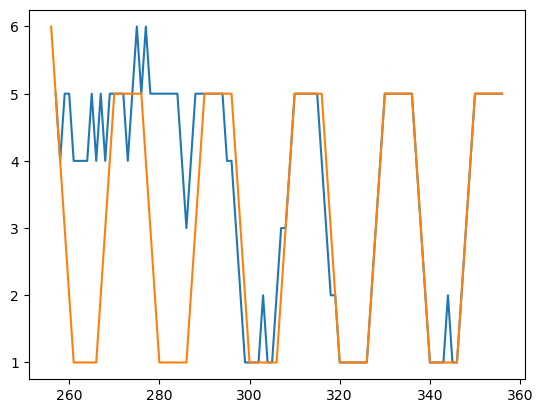

512 train done
512 [np.float64(3.0), 4, 3, 3, 4, 3, 2, 1, 1, 1, 0, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 6, 5, 4, 4, 4, 3, 2, 1, 0, 0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 6, 5, 4, 3, 2, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5] 101
0.30807978879958
750 train done
750 [np.float64(6.0), 5, 5, 5, 4, 5, 6, 5, 4, 5, 4, 4, 4, 4, 3, 3, 3, 3, 4, 5, 5, 5, 5, 4, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 2, 3, 4, 4, 4, 5, 5, 5, 6, 6, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 2, 3, 4, 5] 101
0.37018064078001317
1024 train done
1024 [np.float64(1.0), 0, 1, 2, 3, 4, 5, 5, 5, 4, 4, 5, 4, 4, 3, 2, 1, 1, 1, 1, 2, 1, 1, 2, 3, 4, 5, 5, 5, 5, 6, 6, 5, 4, 3, 2, 1, 1, 1, 1, 0, 1, 2, 3, 4, 4, 5, 5, 5, 5, 4, 3, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 2, 1,

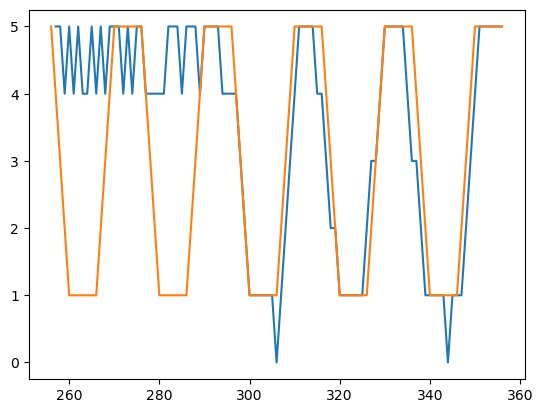

512 train done
512 [np.float64(5.0), 5, 5, 4, 3, 2, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 3, 4, 5, 5, 4, 3, 3, 3, 2, 1, 0, 1, 1, 1, 1, 0, 1, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.516199166347011
750 train done
750 [np.float64(5.0), 5, 6, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 2, 1, 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 3, 3, 4, 5, 5, 6, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 2, 2, 3, 4, 5, 6, 5, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 6, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.4990593214479796
1024 train done
1024 [np.float64(0.0), 1, 2, 2, 3, 4, 5, 5, 5, 4, 5, 5, 4, 3, 2, 2, 1, 1, 1, 0, 1, 1, 2, 2, 3, 4, 5, 5, 6, 5, 4, 5, 4, 3, 2, 2, 1, 1, 1, 0, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 2, 3, 3, 4, 4, 5, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1,

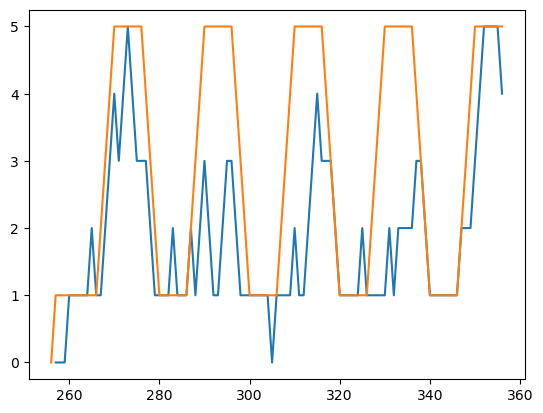

512 train done
512 [np.float64(1.0), 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 6, 5, 5, 5, 6, 5, 4, 3, 2, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 5, 4, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 4, 5, 5, 5] 101
0.39251966458331594
750 train done
750 [np.float64(5.0), 5, 5, 4, 4, 5, 4, 4, 3, 2, 1, 1, 2, 1, 2, 2, 1, 2, 3, 4, 5, 5, 5, 5, 4, 5, 5, 4, 3, 2, 1, 1, 1, 1, 0, 1, 2, 3, 3, 4, 5, 5, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 3, 4, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5] 101
0.1928685464509354
1024 train done
1024 [np.float64(1.0), 2, 3, 3, 3, 4, 5, 6, 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 6, 5, 4, 3, 2, 1, 1, 1, 1, 0, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 4, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 4, 5, 4, 3, 3, 2, 1, 1, 1, 1, 1, 

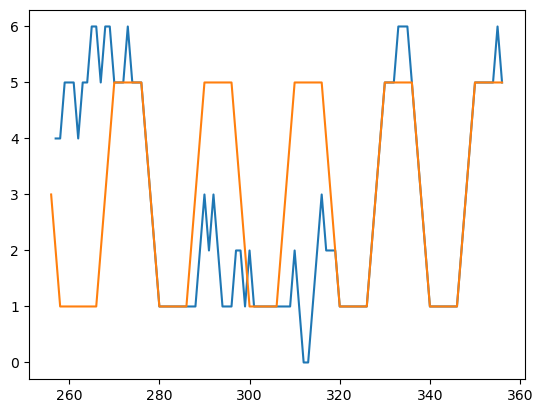

512 train done
512 [np.float64(5.0), 4, 4, 4, 3, 3, 3, 2, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 2, 2, 2, 3, 2, 3, 2, 3, 2, 1, 1, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 0, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.37193178390281845
750 train done
750 [np.float64(2.0), 2, 3, 4, 4, 3, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 4, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 4, 5, 5, 5, 5, 5, 4, 5, 4, 3, 2, 1, 1, 1, 1, 2, 1, 2, 2, 3, 4, 5, 5, 6, 6, 5, 6, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.2204966142818128
1024 train done
1024 [np.float64(6.0), 6, 5, 6, 5, 4, 5, 6, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 2, 1, 0, 1, 1, 1, 2, 3, 4, 5, 5, 5, 4, 4, 3, 3, 2, 1, 1, 1, 1, 2, 3, 4, 4, 4, 5, 4, 5, 5, 5, 5, 4, 3, 3, 3, 3, 2, 1, 1, 0, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 

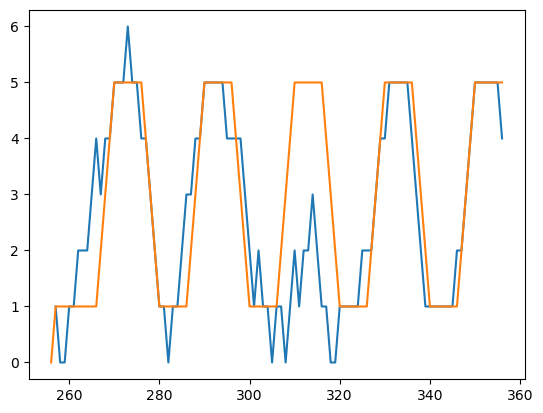

512 train done
512 [np.float64(4.0), 3, 4, 5, 5, 4, 3, 2, 1, 1, 2, 1, 1, 2, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 4, 4, 3, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 6, 5, 5, 5, 5, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 3, 2, 1, 1, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5] 101
0.22696871730526483
750 train done
750 [np.float64(5.0), 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 2, 1, 1, 2, 3, 4, 5, 4, 5, 5, 5, 4, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 2, 3, 4, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 5] 101
0.4494975215399086
1024 train done
1024 [np.float64(0.0), 0, 1, 2, 3, 4, 5, 5, 4, 4, 5, 5, 4, 3, 2, 2, 1, 1, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 3, 3, 2, 1, 1, 1, 2, 1, 1, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 4, 4, 3, 2, 1, 1, 1, 1, 1, 

In [5]:
gamma = 0.9
Ts = [2**i for i in np.arange(7,10)] + [750] + [2**i for i in np.arange(10,12)]

threshold = 1e-4

def softmax(x, tau=1.0):
    x = np.asarray(x, dtype=float)
    z = (x - np.max(x)) / tau
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

def tau_schedule(delta_t, tau0=2.0, tau_min=0.05, decay=0.98):
    return max(tau_min, tau0 * (decay ** delta_t))

for rep in range(10):
    rng = np.random.default_rng(515 + rep)   # reproducible sampling

    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(
            rewards_in_period=rewards_in_period,
            session_duration=500000,
            tdim=50,
            n_sessions=1,
            seed=515 + rep
        )

        state_posencode_oh = position_encoder(states[:, 0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh, states[:, 1:]])

        for T in Ts:
            prewards = make_weighted_target(irewards, gamma, T=T, normalization=False)
            X_train_oh = new_state_oh[:T, :]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]

            rf_value = xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="exact",
                n_jobs=-1,
                learning_rate=0.05,
                max_depth=10,
                subsample=1,
                colsample_bytree=0.8,
                n_estimators=2000,
                eval_metric="rmse"
            )
            rf_value.fit(X_train_oh, Y_train_value)

            rf_action = xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="exact",
                n_jobs=-1,
                learning_rate=0.05,
                max_depth=10,
                subsample=1,
                colsample_bytree=0.8,
                n_estimators=2000,
                eval_metric="rmse"
            )
            rf_action.fit(X_train_oh, Y_train_action)

            print(T, 'train done')

            current_state = states[T, 0]
            future_states = [current_state]

            for delta_t in range(100):
                df_all_paths = enumerate_paths(
                    x0=current_state,
                    t_inital=T + delta_t,
                    t_prime=t_prime
                )

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths, t_prime + 1))

                for i in range(t_prime + 1):
                    cand_pe = position_encoder(df_all_paths.iloc[:, i], type="onehot")
                    curr_time = T + 1 + delta_t + i
                    time_emb = time_embedding_np(
                        np.ones(cand_pe.shape[0]) * curr_time,
                        tdim=50
                    )
                    features = np.hstack([cand_pe, time_emb])
                    irewards_pred[:, i] = rf_action.predict(features)

                reward_cols = [f"t={T + delta_t + t}" for t in range(t_prime + 1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)

                cand_pe = position_encoder(df_all_paths.iloc[:, -1], type='onehot')
                curr_time = T + 1 + delta_t + t_prime + 1
                time_emb = time_embedding_np(
                    np.ones(cand_pe.shape[0]) * curr_time,
                    tdim=50
                )
                features = np.hstack([cand_pe, time_emb])

                prewards_pred = rf_value.predict(features)
                df_ireward["preward"] = prewards_pred

                rewards_matrix = df_ireward.iloc[:, 1:].values
                discounts = gamma ** np.arange(0, t_prime + 1)
                discounted_returns = rewards_matrix * discounts
                total_discounted = discounted_returns.sum(axis=1)

                # -------- softmax instead of argmax --------
                tau = tau_schedule(delta_t, tau0=2.0, tau_min=0.05, decay=0.98)
                probs = softmax(total_discounted, tau=tau)

                chosen_idx = rng.choice(len(total_discounted), p=probs)
                next_state = int(df_all_paths.iloc[chosen_idx, 1])
                # ------------------------------------------

                future_states.append(next_state)
                current_state = next_state

            print(T, future_states, len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [
                reward_simulate(future_states[i], T + i, rewards_in_period)
                for i in np.arange(1, len(future_states))
            ]
            preward = compute_normalized_future_rewards(
                irewards_test, 100, 0.5, normalization=True
            )

            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(
                ireward_opt[1:], 100, 0.5, normalization=True
            )
            pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100
            print(pregret)

            if T == 256:
                plt.plot(np.arange(T + 1, T + 101), future_states[1:])
                plt.plot(np.arange(T, T + 101), path)
                plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/exploration/softmax_GBT_oh_gamma0.9_weighted_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
            future_states=FUTURE_STATE_arr
        )